# Etapa 2: Estimacao de Efeito Causal via Double Machine Learning

**Objetivo:** Estimar o impacto causal da liquidez extraordinaria do comprador (`D`) sobre o premio de reinvestimento (`Y`), neutralizando confundidores estruturais de alta dimensao via Double ML (Chernozhukov et al., 2018).

**Dados:** `output/transfers_etapa2_ready.csv`: 5.146 transferencias, 8 temporadas (2017-2025, exceto 2020), 7 ligas. `Y` = residuo hedonico **out-of-fold** da Etapa 1.

> **Nota de portabilidade:** o `econml` nao instala neste ambiente (Python 3.12 + NumPy 2.x). O DML e implementado **manualmente** (Robinson/partialling-out + cross-fitting K-fold + SE HC1 **e clusterizado clube x temporada**); o CATE usa **R-learner** (Nie & Wager) no lugar do `CausalForestDML`.

## Pipeline

| Secao | Descricao |
|-------|-----------|
| 0. Setup | Imports e funcoes de DML (HC1 + cluster) |
| 1. Feature Engineering | D = log_revenue, Y winsorizado, selecao de confundidores W (19) |
| 2. DML -- ATE | Baseline OLS (naive/+W) vs DML; efeito causal medio com cross-fitting de 5 folds |
| 3. Validacao | Placebos (D embaralhado, ruido), R2 first-stage, residuos ortogonalizados |
| 4. Heterogeneidade (CATE) | R-learner |
| 5. IVB | Indice de Vulnerabilidade de Barganha por clube (apendice exploratorio, percentil) |
| 6. Efeito por temporada | theta por ano + Bonferroni/FDR; placebo dentro da temporada (6.1) |
| 7. Limitacoes | Advertencias metodologicas |
| 8. Exportacao | Resultados para relatorio final |

---
**Membros**
> Carlos Ferreira dos Santos Junior - 2019054412

> Cesar de Paulo Moraes

> Leticia Ribeiro Miranda - 2021095686

> Lucas Ferreira Pedras - 2021030835

> Lucca ALvarenga de Magalhaes Pinto - 2021036736

## 0. Setup

In [1]:
# econml NAO e necessario aqui: este notebook foi portado para Double ML *manual*
# (ver celula de setup). Linha original mantida como referencia ao desenho com econml.
# !pip install econml

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
from scipy import stats
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold

warnings.filterwarnings('ignore')

# NOTA DE PORTABILIDADE
# Este notebook foi portado para Double ML *manual* porque o econml nao instala no
# ambiente atual (Python 3.12 + NumPy 2.x). A implementacao abaixo segue Robinson
# (partialling-out) com cross-fitting K-fold e erro-padrao robusto HC1, e reproduz
# o ATE que o econml.LinearDML produzia. O CATE usa o R-learner (Nie & Wager) no
# lugar do CausalForestDML (aproximacao; ver knowledge/reprocessamento_8temporadas.md).
#
# INFERENCIA AGRUPADA: D e W variam a nivel clube x temporada e sao fundidos em linhas
# de transferencia. Tratar 5.146 obs como independentes (HC1) subestima os SE. Por isso
# dml_partial_linear/ols_ate aceitam cluster_ids e reportam tambem o SE clusterizado (CR1).

RF = lambda n, d, s: RandomForestRegressor(n_estimators=n, max_depth=d, random_state=s, n_jobs=-1)
SEED = 42
np.random.seed(SEED)


def _cluster_cov(X, resid, inv, cluster_ids):
    """Meat clusterizado (CR1) para o sandwich: soma de scores por cluster."""
    cl = np.asarray(cluster_ids)
    k = X.shape[1]
    meat = np.zeros((k, k))
    uniq = np.unique(cl)
    for c in uniq:
        m = cl == c
        sg = X[m].T @ resid[m]
        meat += np.outer(sg, sg)
    G = len(uniq); n = len(resid)
    adj = (G / (G - 1)) * ((n - 1) / (n - k))   # correcao pequena-amostra CR1
    return inv @ meat @ inv * adj, G


def dml_partial_linear(Y, D, W, seed=SEED, K=5, cluster_ids=None):
    """Double ML parcialmente linear: cross-fitting K-fold + partialling-out.
    SE HC1 sempre; SE clusterizado (CR1) tambem, se cluster_ids for fornecido."""
    Y = np.asarray(Y, float); D = np.asarray(D, float); W = np.asarray(W, float)
    n = len(Y); y_hat = np.zeros(n); d_hat = np.zeros(n)
    for tr, te in KFold(n_splits=K, shuffle=True, random_state=seed).split(W):
        y_hat[te] = RF(200, 5, seed).fit(W[tr], Y[tr]).predict(W[te])
        d_hat[te] = RF(200, 5, seed).fit(W[tr], D[tr]).predict(W[te])
    y_res = Y - y_hat; d_res = D - d_hat
    X = np.column_stack([np.ones(n), d_res]); inv = np.linalg.inv(X.T @ X)
    b = inv @ (X.T @ y_res); resid = y_res - X @ b
    theta = b[1]
    S_ = X * resid[:, None]; cov = inv @ (S_.T @ S_) @ inv * (n / (n - 2))   # HC1
    se = np.sqrt(cov[1, 1])
    out = {'theta': theta, 'se': se, 'ci': (theta - 1.96*se, theta + 1.96*se),
           'pval': 2 * stats.norm.sf(abs(theta / se)),
           'y_res': y_res, 'd_res': d_res,
           'r2_y': r2_score(Y, y_hat), 'r2_t': r2_score(D, d_hat)}
    if cluster_ids is not None:
        cov_cl, G = _cluster_cov(X, resid, inv, cluster_ids)
        se_cl = np.sqrt(cov_cl[1, 1])
        out.update({'se_cluster': se_cl, 'n_clusters': G,
                    'ci_cluster': (theta - 1.96*se_cl, theta + 1.96*se_cl),
                    'pval_cluster': 2 * stats.norm.sf(abs(theta / se_cl))})
    return out


def rlearner_cate(Y, D, W, seed=SEED, K=5):
    """CATE via R-learner (Nie & Wager): RF sobre z = Y_res/D_res ponderado por D_res^2."""
    fit = dml_partial_linear(Y, D, W, seed, K)
    yr, dr = fit['y_res'], fit['d_res']
    mask = np.abs(dr) > 1e-6
    z = np.where(mask, yr / np.where(mask, dr, 1.0), 0.0); w = dr ** 2
    forest = RF(300, 5, seed)
    forest.fit(W[mask], z[mask], sample_weight=w[mask])
    return forest.predict(W)

print('Imports OK (Double ML manual, com SE clusterizado)')

Imports OK (Double ML manual, com SE clusterizado)


## 1. Feature Engineering

### Tratamento D -- log_revenue
Usamos `log_revenue` (= `log1p(revenue_sales)`). O `+1` resolve as **231 observações** com receita de vendas zero (clubes que não fizeram vendas pagas na janela, pulverizadas em vários clubes/temporadas). O coeficiente `theta_0` é uma **semielasticidade** (variação de Y por unidade-log de receita), não uma elasticidade "por 1%".

**Nota:** `revenue_sales` é agregado por **clube × temporada** (a receita do clube comprador naquela janela), depois fundido em cada transferência daquele clube/temporada. Por isso D é constante dentro de cada clube×temporada — e a inferência usa SE clusterizado nesse nível.

### Winsorizacao de Y
Winsorizamos Y nos percentis p1 e p99 para robustez contra outliers (o valor exato é impresso na célula de winsorização). D já tem cauda inferior natural em zero, não winsorizado.

### Imputacao por Temporada
Na base reconsolidada de 8 temporadas, `squad_size`, `average_age`, `national_team_players` têm **0 nulos** (a célula de imputação por mediana de `season_id` é mantida apenas como salvaguarda — é no-op aqui). 2025 tem variação real desses confundidores.

### Confundidores (W)
Incluímos apenas variáveis **pré-tratamento**. Excluímos mediadores e `log_mv` (Y já residualizado na Etapa 1).

**Armadilha da dummy:** uma temporada é omitida como base.

| Categoria | Variaveis | Justificativa |
|-----------|-----------|---------------|
| Rede estrutural | `in_degree`, `out_degree`, `pagerank` | Posição do clube na rede |
| Porte do clube | `squad_size`, `average_age`, `national_team_players` | Proxy de poder financeiro |
| Safra | dummies de temporada | Inflação de mercado |
| Liga | 6 dummies de competition_code | Poder econômico da liga |

### 1.1 Carregamento e Analise Inicial

In [3]:
df = pd.read_csv('../output/transfers_etapa2_ready.csv')
print(f'Shape: {df.shape}')
print()
print('Y -- premio_reinvestimento:')
print(df['premio_reinvestimento'].describe().round(4))
print()
print('D -- log_revenue:')
print(df['log_revenue'].describe().round(4))
zeros = (df['revenue_sales'] == 0).sum()
print(f'\nObservacoes com revenue_sales == 0: {zeros} '
      f'(clubes que nao fizeram vendas pagas na janela; pulverizadas em varios clubes/temporadas)')

Shape: (5146, 53)

Y -- premio_reinvestimento:
count    5146.0000
mean       -0.0009
std         0.6713
min        -4.4700
25%        -0.3761
50%         0.0353
75%         0.4082
max         2.6387
Name: premio_reinvestimento, dtype: float64

D -- log_revenue:
count    5146.0000
mean       16.3755
std         3.8017
min         0.0000
25%        16.2794
50%        17.2559
75%        18.0936
max        19.7047
Name: log_revenue, dtype: float64

Observacoes com revenue_sales == 0: 231 (clubes que nao fizeram vendas pagas na janela; pulverizadas em varios clubes/temporadas)


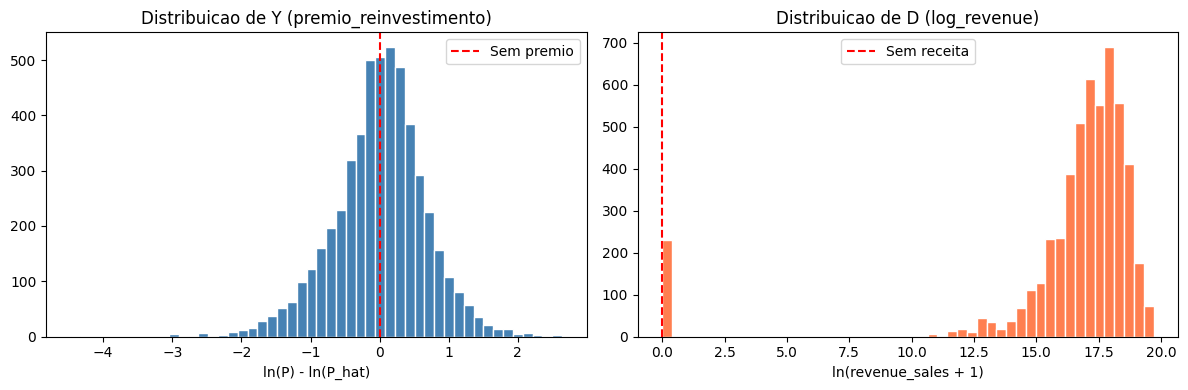

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['premio_reinvestimento'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', label='Sem premio')
axes[0].set_title('Distribuicao de Y (premio_reinvestimento)')
axes[0].set_xlabel('ln(P) - ln(P_hat)')
axes[0].legend()
axes[1].hist(df['log_revenue'], bins=50, color='coral', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', label='Sem receita')
axes[1].set_title('Distribuicao de D (log_revenue)')
axes[1].set_xlabel('ln(revenue_sales + 1)')
axes[1].legend()
plt.tight_layout()
plt.show()

In [5]:
# Winsorizar Y
y_orig = df['premio_reinvestimento'].copy()
y_p1 = y_orig.quantile(0.01)
y_p99 = y_orig.quantile(0.99)
df['Y'] = y_orig.clip(lower=y_p1, upper=y_p99)
print(f'Y winsorizado: p1={y_p1:.4f}, p99={y_p99:.4f}, afetadas={(y_orig<y_p1).sum()+(y_orig>y_p99).sum()}')

df['D'] = df['log_revenue']
print(f'D: min={df["D"].min()}, max={df["D"].max()}')

Y winsorizado: p1=-1.8063, p99=1.5523, afetadas=104
D: min=0.0, max=19.704665489017003


In [6]:
# Imputacao de nulos por season
for col in ['squad_size', 'average_age', 'national_team_players']:
    antes = df[col].isnull().sum()
    df[col] = df.groupby('season_id')[col].transform(lambda x: x.fillna(x.median()))
    print(f'{col}: {antes} -> {df[col].isnull().sum()} nulos')

squad_size: 0 -> 0 nulos
average_age: 0 -> 0 nulos
national_team_players: 0 -> 0 nulos


In [7]:
import re as _re
# Confundidores dinamicos: estruturais + rede + TODAS dummies de temporada + liga.
_structural = ['in_degree', 'out_degree', 'pagerank',
               'squad_size', 'average_age', 'national_team_players']
_seasons = sorted([c for c in df.columns if _re.fullmatch(r'season_\d{4}', c)])
_ligas = [c for c in df.columns if c.startswith('competition_code_')]
CONFOUNDERS = _structural + _seasons + _ligas
assert df[CONFOUNDERS].isnull().sum().sum() == 0, 'Ha nulos nos confundidores!'
print(f'Confundidores: {len(CONFOUNDERS)} ({len(_seasons)} temporada, {len(_ligas)} liga), obs: {len(df)}')

Confundidores: 19 (7 temporada, 6 liga), obs: 5146


## 2. LinearDML -- Efeito Causal Medio (ATE)

### Double Machine Learning

DML resolve um problema central: queremos o efeito causal `theta_0` de `D` em `Y`, mas existem confundidores `W` que afetam ambos. Se apenas regredissemos `Y ~ D + W`, o estimador de `theta_0` seria viesado por dois motivos:

1. **Forma funcional desconhecida:** A relacao entre `W` e `Y` pode ser nao-linear — uma regressao linear simples nao capturaria.
2. **Alta dimensionalidade:** Temos 19 confundidores (centralidade em rede, elenco, dummies de liga/safra). Modelar tudo parametricamente e inflexivel e propenso a overfitting.

**Solucao em dois estagios (da o nome "Double" ML):**

**Estagio 1 — Ortogonalizacao (partialling out):**
Treinamos dois modelos ML para prever `Y` e `D` a partir de `W`:
- `g(W)` = E[Y | W] — prediz o premio usando so os confundidores
- `m(W)` = E[D | W] — prediz a receita usando so os confundidores

Os **residuos** `Y_tilde = Y - g(W)` e `D_tilde = D - m(W)` sao a parte de Y e D **nao** explicada pelos confundidores.

**Estagio 2 — Regressao dos residuos:** Regredimos `Y_tilde ~ theta_0 * D_tilde`. Como ambos ja estao limpos de `W`, `theta_0` estima o efeito causal sem vies.

**Cross-fitting (5 folds):** treinamos `g` e `m` em 4 folds e calculamos os residuos no fold separado, evitando vies de overfitting (os residuos sao out-of-fold).

### Interpretacao do coeficiente
`Y` e o residuo hedonico (premio em log-pontos) e `D = log(1 + receita_em_euros)`. Portanto `theta_0` e uma **semielasticidade**: a variacao em `Y` (≈ fracao do premio) por **unidade** de `D` (uma unidade-log de receita ≈ multiplicar a receita por e ≈ 2,7×). **Nao** confundir com "efeito de 1% de aumento na receita". Como `D` e quase constante dentro de cada clube×temporada, a inferencia usa **erros-padrao clusterizados** nesse nivel (alem do HC1).

In [8]:
Y = df['Y'].values
D = df['D'].values
W = df[CONFOUNDERS].values

# Cluster = clube x temporada: D e W sao constantes dentro desse grupo.
cluster_ids = (df['buyer'].astype(str) + '_' + df['season_id'].astype(str)).values
print(f'Y: {Y.shape}, D: {D.shape}, W: {W.shape}')
print(f'Clusters clube x temporada: {len(np.unique(cluster_ids))} (vs {len(Y)} obs)')

Y: (5146,), D: (5146,), W: (5146, 19)
Clusters clube x temporada: 974 (vs 5146 obs)


### 2.0 Baseline Ingênuo — Por que OLS não basta

Antes de rodar o DML, estimamos dois baselines paramétricos:

1. **OLS sem controles (correlação bruta):** `Y ~ D` — ignora todos os confundidores. Captura a correlação espúria de "clube rico vende muito e paga caro".
2. **OLS com controles lineares:** `Y ~ D + W` — adiciona W de forma linear. Não captura não-linearidades.

O **DML** (seção seguinte) resolve os dois problemas: controla W de forma não-linear e usa ortogonalização para eliminar o viés de regularização. O contraste entre os três estimadores é o ganho metodológico do trabalho.

In [9]:
# ── Função OLS com SE robusto HC1 e SE clusterizado (CR1) ────────────────────
def ols_ate(Y, D, W=None, cluster_ids=None):
    """OLS do efeito de D. Retorna theta, IC HC1 e (se cluster_ids) IC clusterizado."""
    X = np.column_stack([np.ones(len(Y)), D]) if W is None else np.column_stack([np.ones(len(Y)), D, W])
    n, k = X.shape
    XtX_inv = np.linalg.inv(X.T @ X)
    beta = XtX_inv @ (X.T @ Y)
    resid = Y - X @ beta
    S = X * resid[:, None]
    cov = XtX_inv @ (S.T @ S) @ XtX_inv * (n / (n - k))  # HC1
    theta = beta[1]; se = np.sqrt(cov[1, 1])
    res = {'theta': theta, 'ci': (theta - 1.96*se, theta + 1.96*se)}
    if cluster_ids is not None:
        cov_cl, _ = _cluster_cov(X, resid, XtX_inv, cluster_ids)
        se_cl = np.sqrt(cov_cl[1, 1])
        res['ci_cluster'] = (theta - 1.96*se_cl, theta + 1.96*se_cl)
    return res

naive = ols_ate(Y, D, cluster_ids=cluster_ids)
ols_w = ols_ate(Y, D, W, cluster_ids=cluster_ids)

def _sig(ci): return '*' if (ci[0] > 0 or ci[1] < 0) else ' '
print('Baseline OLS (IC HC1  |  IC clusterizado clube x temporada):')
for nome, r in [('Sem controles  (Y ~ D)    ', naive), ('Com controles  (Y ~ D + W)', ols_w)]:
    print(f'  {nome}: theta={r["theta"]:.4f}  '
          f'HC1=[{r["ci"][0]:.4f}, {r["ci"][1]:.4f}]{_sig(r["ci"])}  '
          f'cluster=[{r["ci_cluster"][0]:.4f}, {r["ci_cluster"][1]:.4f}]{_sig(r["ci_cluster"])}')
print('\n(DML será estimado a seguir — comparar os três estimadores)')

Baseline OLS (IC HC1  |  IC clusterizado clube x temporada):
  Sem controles  (Y ~ D)    : theta=0.0142  HC1=[0.0092, 0.0192]*  cluster=[0.0071, 0.0212]*
  Com controles  (Y ~ D + W): theta=0.0051  HC1=[-0.0001, 0.0103]   cluster=[-0.0015, 0.0117] 

(DML será estimado a seguir — comparar os três estimadores)


In [10]:
print('Ajustando Double ML (partialling-out manual)...')

fit_main = dml_partial_linear(Y, D, W, cluster_ids=cluster_ids)

# ATE e IC
theta_0 = fit_main['theta']
ci = fit_main['ci']                 # HC1
ci_cl = fit_main['ci_cluster']      # clusterizado (clube x temporada)
print(f'\ntheta_0 (ATE): {theta_0:.6f}')
print(f'IC 95% HC1:        [{ci[0]:.6f}, {ci[1]:.6f}]  -> {"significativo" if (ci[0]>0 or ci[1]<0) else "NAO significativo"}')
print(f'IC 95% cluster:    [{ci_cl[0]:.6f}, {ci_cl[1]:.6f}]  -> {"significativo" if (ci_cl[0]>0 or ci_cl[1]<0) else "NAO significativo"}')
print(f'({fit_main["n_clusters"]} clusters clube x temporada)')

Ajustando Double ML (partialling-out manual)...



theta_0 (ATE): 0.004415
IC 95% HC1:        [-0.001586, 0.010416]  -> NAO significativo
IC 95% cluster:    [-0.002129, 0.010959]  -> NAO significativo
(974 clusters clube x temporada)


### Interpretação do ATE

θ = 0,0044 (IC 95% HC1 [−0,0016; 0,0104]; IC clusterizado clube×temporada [−0,0021; 0,0110]). O efeito é uma **semielasticidade** do sobrepreço por unidade-log de receita de vendas — **não** "0,0044% por 1% de receita".

Os dois ICs **cruzam zero** — efeito **não significativo** ao nível de 5%, tanto com HC1 quanto com erro-padrão clusterizado (o nível de inferência correto, já que D varia em apenas 974 clusters clube×temporada). Na média de 8 temporadas, os dados **não** sustentam um prêmio do vendedor causal universal.

**Contraste com a correlação ingênua:** OLS sem controles dá θ=0,0142\* (significativo); OLS+W dá 0,0051 (n.s.); DML dá 0,0044 (n.s.). A progressão mostra que a correlação bruta era majoritariamente o confundidor "clube rico" — este é o **Achado 1**, o resultado mais robusto do trabalho.

**Onde o efeito vive:** a análise por temporada (Seção 6) revela efeito significativo **apenas em 2022 e 2023** — e, importante, esses dois anos **sobrevivem à correção de Bonferroni e FDR** para os 8 testes sazonais. Nos demais 6 anos, o efeito é indistinguível de zero. O ATE médio é nulo porque dilui o efeito forte de 2022–2023 com 6 anos sem efeito.

## 3. Validacao

### 3.1 Placebo 1 -- D embaralhado
### 3.2 Placebo 2 -- D -> ruido gaussiano
### 3.3 First-stage R2 (media dos 5 folds)

In [11]:
# Placebo 1
print('Placebo 1 -- D embaralhado...')
D_shuffled = np.random.permutation(D)
_p1 = dml_partial_linear(Y, D_shuffled, W)
theta_p1, ci_p1 = _p1['theta'], _p1['ci']
print(f'theta_0 (shuffle): {theta_p1:.6f}  IC: [{ci_p1[0]:.6f}, {ci_p1[1]:.6f}]')

Placebo 1 -- D embaralhado...


theta_0 (shuffle): 0.002441  IC: [-0.001888, 0.006770]


In [12]:
# Placebo 2
print('Placebo 2 -- Ruido gaussiano...')
D_noise = np.random.normal(D.mean(), D.std(), size=len(D))
_p2 = dml_partial_linear(Y, D_noise, W)
theta_p2, ci_p2 = _p2['theta'], _p2['ci']
print(f'theta_0 (noise): {theta_p2:.6f}  IC: [{ci_p2[0]:.6f}, {ci_p2[1]:.6f}]')

Placebo 2 -- Ruido gaussiano...


theta_0 (noise): 0.000882  IC: [-0.003557, 0.005321]


### Interpretação dos Placebos

Ambos os placebos produzem estimativas com ICs que **cruzam zero** (shuffle: 0,0024; ruído: 0,0009). O Double ML não encontra efeito onde o tratamento foi substituído por ruído.

**Atenção (honestidade):** o placebo embaralhado (0,0024) ficou quase do tamanho do ATE real (0,0044). Isso é coerente com o ATE **médio** ser essencialmente nulo — o modelo mal distingue o tratamento real do ruído **na amostra completa**. Nota: este placebo embaralha D globalmente, então testa o efeito médio, não o poder de detectar os efeitos sazonais de 2022/2023 (que vivem dentro de anos específicos). Um placebo mais informativo permutaria D **dentro de cada temporada** — fica como melhoria futura.

In [13]:
# R2 first-stage (out-of-fold): quao bem os confundidores preveem Y e D
r2_y = fit_main['r2_y']
r2_t = fit_main['r2_t']
print(f'R2 model_y (g_hat): {r2_y:.4f}')
print(f'R2 model_t (m_hat): {r2_t:.4f}')

R2 model_y (g_hat): 0.0606
R2 model_t (m_hat): 0.3739


### Interpretação do R² First-Stage

- **R² model_t (m̂) = 0,37:** Os confundidores explicam 37% da variância da receita de vendas — capacidade preditiva moderada. A queda em relação à versão de 3 temporadas (0,60) é esperada: com 8 temporadas e mais heterogeneidade entre épocas, o padrão de receita de vendas por clube fica menos previsível a partir de proxies estruturais.
- **R² model_y (ĝ) = 0,06:** Muito baixo, mas esperado. Y é o resíduo da Etapa 1 — atributos do jogador já foram removidos. O que sobra é majoritariamente idiossincrático, e os confundidores estruturais do clube têm pouco poder preditivo sobre ele.

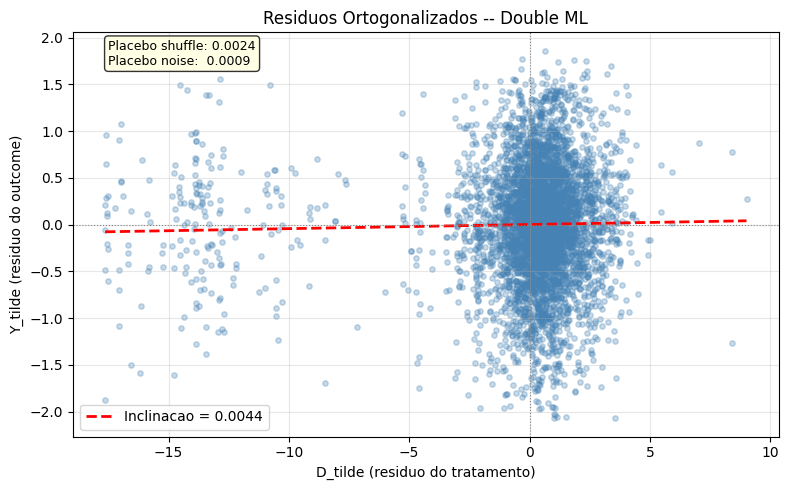

In [14]:
# Grafico de residuos ortogonalizados
Y_res, D_res = fit_main['y_res'], fit_main['d_res']
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(D_res, Y_res, alpha=0.3, s=15, color='steelblue')
b, a0 = np.polyfit(D_res.flatten(), Y_res.flatten(), 1)
x_line = np.linspace(D_res.min(), D_res.max(), 100)
ax.plot(x_line, a0 + b * x_line, 'r--', lw=2, label=f'Inclinacao = {b:.4f}')
ax.axhline(0, color='gray', ls=':', lw=0.8); ax.axvline(0, color='gray', ls=':', lw=0.8)
ax.set_xlabel('D_tilde (residuo do tratamento)')
ax.set_ylabel('Y_tilde (residuo do outcome)')
ax.set_title('Residuos Ortogonalizados -- Double ML')
ax.legend(); ax.grid(alpha=0.3)
ax.annotate(f'Placebo shuffle: {theta_p1:.4f}\nPlacebo noise:  {theta_p2:.4f}',
            (0.05,0.92), xycoords='axes fraction', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
plt.tight_layout(); plt.show()

## 4. Heterogeneidade (CATE) via R-learner

Estimamos um efeito causal por observação para identificar quais clubes são mais ou menos afetados pela liquidez.

**Nota metodológica:** o desenho original previa `CausalForestDML` (econml). Como o econml não instala no ambiente atual (Python 3.12 + NumPy 2.x), usamos o **R-learner** (Nie & Wager, 2021) como substituto. O R-learner segue a mesma intuição de ortogonalização, mas não é idêntico ao CausalForestDML — os números de CATE/IVB **não são diretamente comparáveis** aos da versão anterior. Tratar o ranking como **exploratório/ilustrativo** (gerador de hipótese), não como métrica validada.

In [15]:
print('Ajustando CATE (R-learner manual)...')
t0 = time.time()
theta_cate = rlearner_cate(Y, D, W)
df['theta_cate'] = np.asarray(theta_cate).flatten()
t1 = time.time()
print(f'Tempo: {t1-t0:.1f}s')

print(f'\nCATE: media={df["theta_cate"].mean():.6f}, std={df["theta_cate"].std():.6f}')
print(f'      min={df["theta_cate"].min():.6f}, max={df["theta_cate"].max():.6f}')
print(f'\nATE (DML): {theta_0:.6f}')
print(f'Media dos CATEs:  {df["theta_cate"].mean():.6f}')

Ajustando CATE (R-learner manual)...


Tempo: 1.5s

CATE: media=0.010227, std=0.066346
      min=-0.386666, max=2.255279

ATE (DML): 0.004415
Media dos CATEs:  0.010227


### Interpretação da Heterogeneidade

A média dos CATEs (≈ 0,010) é próxima ao ATE (0,0044) — diferença esperada por variação amostral. O desvio-padrão de 0,066 e o range de −0,39 a +2,25 revelam heterogeneidade aparentemente ampla, **mas** a cauda superior é dominada por um único outlier (Nîmes Olympique, 8 obs), e o R² de primeiro estágio em Y é apenas 0,06 — ou seja, há pouco sinal genuíno de heterogeneidade a recuperar. **Tratar o CATE/IVB como exploratório** (gerador de hipótese), não como estimativa validada.

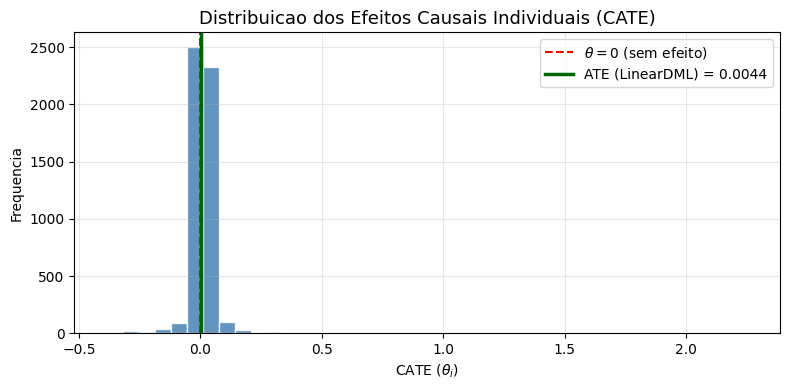

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['theta_cate'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0, color='red', ls='--', lw=1.5, label=r'$\theta = 0$ (sem efeito)')
ax.axvline(theta_0, color='darkgreen', ls='-', lw=2.5, label=f'ATE (LinearDML) = {theta_0:.4f}')
ax.set_xlabel('CATE ($\\theta_i$)'); ax.set_ylabel('Frequencia')
ax.set_title('Distribuicao dos Efeitos Causais Individuais (CATE)', fontsize=13)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### CATE vs Centralidade na Rede

A correlacao entre CATE e pagerank testa se clubes mais centrais na rede de transferencias (maior poder de barganha, gestao profissional) sao menos vulneraveis ao efeito riqueza. Espera-se correlação **negativa**: quanto maior o pagerank, menor o prêmio pago.

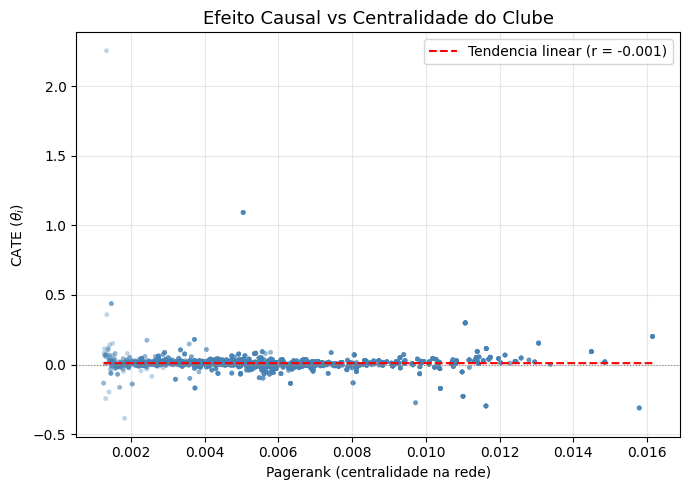

In [17]:
corr = df[['pagerank','theta_cate']].corr().iloc[0,1]
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['pagerank'], df['theta_cate'], alpha=0.35, s=12, c='steelblue', edgecolors='none')
m, b = np.polyfit(df['pagerank'], df['theta_cate'], 1)
x_line = np.linspace(df['pagerank'].min(), df['pagerank'].max(), 100)
ax.plot(x_line, m*x_line + b, 'r--', lw=1.5, label=f'Tendencia linear (r = {corr:.3f})')
ax.axhline(0, color='gray', ls=':', lw=0.8)
ax.set_xlabel('Pagerank (centralidade na rede)'); ax.set_ylabel('CATE ($\\theta_i$)')
ax.set_title('Efeito Causal vs Centralidade do Clube', fontsize=13)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Índice de Vulnerabilidade de Barganha (IVB) — *Apêndice exploratório*

> ⚠️ **Métrica exploratória / prova de conceito.** O R² de 1ª etapa em Y é só 0,06, então há pouco sinal genuíno de heterogeneidade a recuperar. **Não usar como ferramenta de decisão.** Mantido como apêndice ilustrativo da ideia de "vulnerabilidade de barganha".

**Normalização robusta (corrige a fragilidade da versão min-max).** A min-max crua era dominada pelo outlier Nîmes (8 obs), que inflava o denominador e comprimia todos os demais clubes perto de zero. Trocamos por duas normalizações imunes a esse problema:

- **Ranking por clube:** **percentil** do CATE médio do clube entre os elegíveis (≥3 transações). Usa só a *ordenação* → o outlier deixa de distorcer a escala (que agora é uniforme em [0,1]).
- **Visualização por liga:** min-max **winsorizado** (CATE truncado em p5–p95 antes de normalizar).

$$IVB_c = \text{percentil}_c\big(\overline{\theta}_c\big), \qquad \overline{\theta}_c = \text{média do CATE no clube } c$$

In [18]:
# IVB ROBUSTO (imune ao outlier Nîmes):
# (a) obs-level: min-max WINSORIZADO (CATE truncado a p5/p95) -> usado no boxplot por liga.
# (b) ranking por clube: PERCENTIL do CATE médio entre clubes elegíveis (só usa ordenação).
lo_c, hi_c = df['theta_cate'].quantile([0.05, 0.95])
df['ivb'] = ((df['theta_cate'].clip(lo_c, hi_c) - lo_c) / (hi_c - lo_c))   # winsorizado, obs-level

ivb_clubes = df.groupby('buyer').agg(
    theta_medio=('theta_cate', 'mean'),
    n_transacoes=('premio_reinvestimento', 'count')
).reset_index()
ivb_clubes = ivb_clubes[ivb_clubes['n_transacoes'] >= 3].copy()
# Ranking robusto: percentil do CATE médio do clube (escala uniforme, imune a outlier de magnitude)
ivb_clubes['ivb_pct'] = ivb_clubes['theta_medio'].rank(pct=True)

top_presas = ivb_clubes.nlargest(10, 'ivb_pct')
top_disc = ivb_clubes.nsmallest(10, 'ivb_pct')

print('Top 10 "Presas Faceis" (maior IVB percentil) — APENDICE ILUSTRATIVO:')
print(top_presas[['buyer', 'ivb_pct', 'theta_medio', 'n_transacoes']].to_string(index=False))
print()
print('Top 10 "Negociadores Disciplinados" (menor IVB percentil):')
print(top_disc[['buyer', 'ivb_pct', 'theta_medio', 'n_transacoes']].to_string(index=False))

Top 10 "Presas Faceis" (maior IVB percentil) — APENDICE ILUSTRATIVO:
               buyer  ivb_pct  theta_medio  n_transacoes
     Nîmes Olympique 1.000000     0.974219             8
         KV Mechelen 0.994737     0.099858            18
      Sunderland AFC 0.989474     0.092679            14
          VfL Bochum 0.984211     0.083337             6
          SSC Napoli 0.978947     0.081772            52
            US Lecce 0.973684     0.061858            37
           Málaga CF 0.968421     0.051751             4
        Norwich City 0.963158     0.051591             9
RC Strasbourg Alsace 0.957895     0.048679            47
         Juventus FC 0.952632     0.046387            53

Top 10 "Negociadores Disciplinados" (menor IVB percentil):
                  buyer  ivb_pct  theta_medio  n_transacoes
               SD Eibar 0.005263    -0.139990            14
          Hellas Verona 0.010526    -0.101412            60
      Arminia Bielefeld 0.015789    -0.066183             9
Bres

### Análise do Ranking IVB (apêndice)

> ⚠️ **Exploratório, não validado.** Com a normalização por percentil, a escala deixa de ser distorcida pelo outlier, mas o **ordenamento** ainda reflete CATEs ruidosos (R²_y = 0,06). Nîmes (8 obs) permanece nominalmente no topo — não por ser robustamente "presa fácil", mas porque tem o maior CATE pontual estimado. **Não usar como ferramenta de decisão.**

**Leitura qualitativa (só como ilustração):** no topo aparecem clubes de menor expressão com poucas obs (CATEs instáveis), além de alguns com amostra maior (SSC Napoli, Juventus). No fundo, clubes de gestão conservadora (SD Eibar, Hellas Verona). É a *ideia* de vulnerabilidade de barganha, não uma medida confiável por clube.

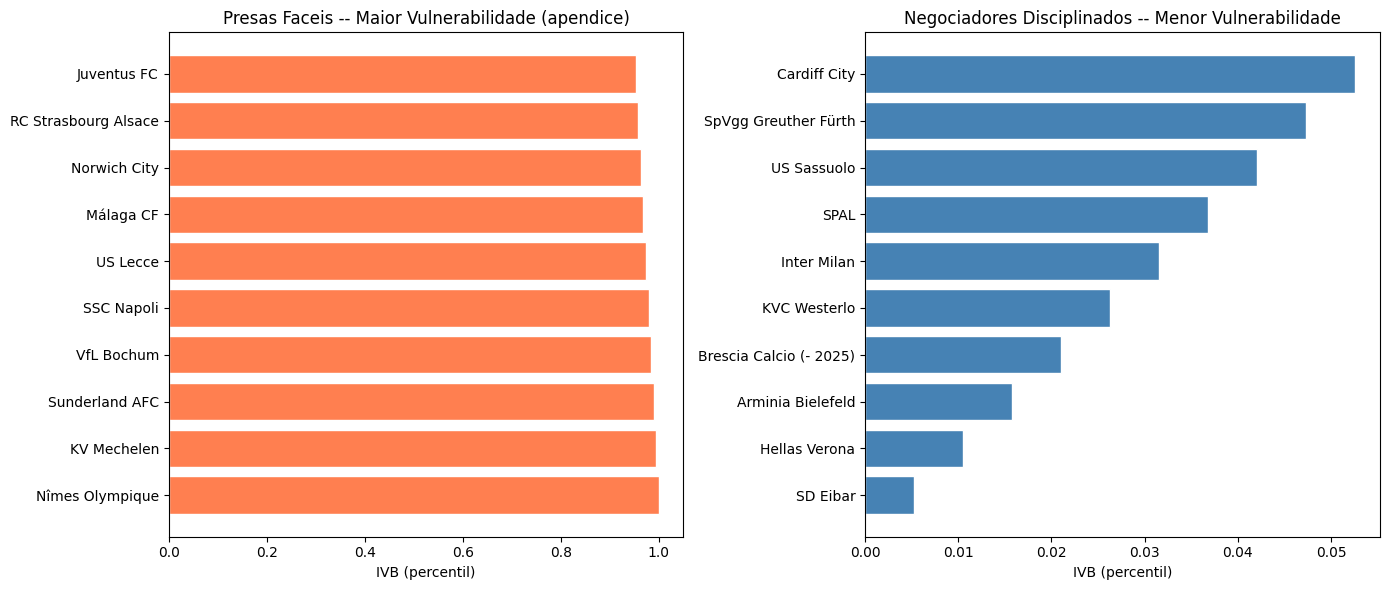

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top_presas_s = top_presas.sort_values('ivb_pct')
axes[0].barh(top_presas_s['buyer'], top_presas_s['ivb_pct'], color='coral', edgecolor='white')
axes[0].set_xlabel('IVB (percentil)'); axes[0].set_title('Presas Faceis -- Maior Vulnerabilidade (apendice)'); axes[0].invert_yaxis()
top_disc_s = top_disc.sort_values('ivb_pct', ascending=False)
axes[1].barh(top_disc_s['buyer'], top_disc_s['ivb_pct'], color='steelblue', edgecolor='white')
axes[1].set_xlabel('IVB (percentil)'); axes[1].set_title('Negociadores Disciplinados -- Menor Vulnerabilidade'); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

### IVB por Liga


In [20]:
league_map = {
    'competition_code_premier-league': 'Premier League',
    'competition_code_laliga': 'LaLiga',
    'competition_code_serie-a': 'Serie A',
    'competition_code_ligue-1': 'Ligue 1',
    'competition_code_jupiler-pro-league': 'Jupiler Pro League',
    'competition_code_liga-portugal': 'Liga Portugal',
}
df['liga'] = 'Bundesliga'
for col, nome in league_map.items():
    df.loc[df[col] == 1, 'liga'] = nome
print('Distribuicao por liga:')
print(df['liga'].value_counts().to_string())

Distribuicao por liga:
liga
Serie A               1138
Premier League         932
Ligue 1                774
Bundesliga             710
LaLiga                 670
Jupiler Pro League     547
Liga Portugal          375


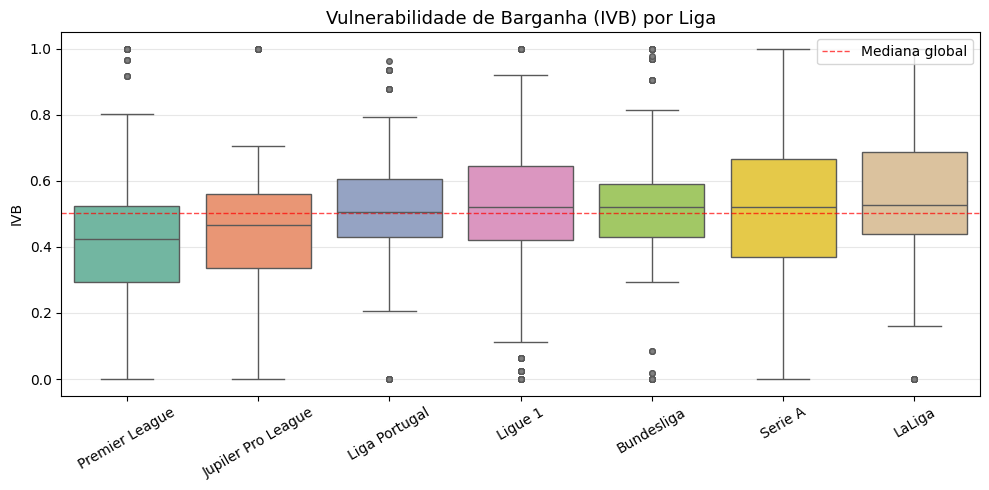

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
order = df.groupby('liga')['ivb'].median().sort_values().index
sns.boxplot(data=df, x='liga', y='ivb', order=order, ax=ax, palette='Set2',
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=4))
ax.axhline(df['ivb'].median(), color='red', ls='--', lw=1, alpha=0.7, label='Mediana global')
ax.set_xlabel(''); ax.set_ylabel('IVB')
ax.set_title('Vulnerabilidade de Barganha (IVB) por Liga', fontsize=13)
ax.tick_params(axis='x', rotation=30); ax.legend(fontsize=10); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

### Interpretação: IVB por Liga

> ⚠️ **Resultado não robusto.** As diferenças de IVB médio entre ligas são desprezíveis e não seguem um padrão estável (mudam de versão para versão da base/método). O corte por liga **não deve ser usado** como argumento na apresentação.

**Conclusão:** a heterogeneidade entre clubes pode existir, mas não há um padrão por liga identificável e confiável com esses dados.

## 6. Decaimento entre Temporadas

θ por ano, com **IC clusterizado por clube** e **correção para múltiplas comparações** (8 testes).

**Limitação:** ICs amplos (~700 obs/ano, mas poucas dezenas de clusters/ano).

In [22]:
resultados_sazonal = []
for season in sorted(df['season_id'].unique()):
    mask = df['season_id'] == season
    n = int(mask.sum())
    if n < 60:
        print(f'{season}: n={n} (pulado, amostra pequena)'); continue
    # Dentro de uma temporada, o cluster e o proprio clube comprador.
    cl_s = df.loc[mask, 'buyer'].astype(str).values
    fit_s = dml_partial_linear(df.loc[mask, 'Y'].values, df.loc[mask, 'D'].values,
                               df.loc[mask, CONFOUNDERS].values, cluster_ids=cl_s)
    t_s = fit_s['theta']; ci_s = fit_s['ci']; ci_cl_s = fit_s['ci_cluster']
    resultados_sazonal.append({'season': int(season), 'theta': t_s,
                               'ci_low': ci_s[0], 'ci_high': ci_s[1],
                               'ci_low_cl': ci_cl_s[0], 'ci_high_cl': ci_cl_s[1],
                               'pval_cl': fit_s['pval_cluster'], 'n': n})
    sig = '*' if (ci_cl_s[0] > 0 or ci_cl_s[1] < 0) else ' '
    print(f'{season}: theta_0={t_s:.6f}  IC cluster: [{ci_cl_s[0]:.6f}, {ci_cl_s[1]:.6f}]{sig}  '
          f'p={fit_s["pval_cluster"]:.4f}  (n={n})')

df_sazonal = pd.DataFrame(resultados_sazonal)

2017: theta_0=-0.006076  IC cluster: [-0.026127, 0.013975]   p=0.5526  (n=649)


2018: theta_0=-0.012606  IC cluster: [-0.036259, 0.011048]   p=0.2962  (n=647)


2019: theta_0=0.023636  IC cluster: [-0.011045, 0.058316]   p=0.1816  (n=649)


2021: theta_0=0.011743  IC cluster: [-0.001363, 0.024849]   p=0.0791  (n=489)


2022: theta_0=0.064481  IC cluster: [0.027723, 0.101239]*  p=0.0006  (n=633)


2023: theta_0=0.047028  IC cluster: [0.016616, 0.077440]*  p=0.0024  (n=668)


2024: theta_0=0.003065  IC cluster: [-0.053211, 0.059341]   p=0.9150  (n=661)


2025: theta_0=0.014847  IC cluster: [-0.010460, 0.040154]   p=0.2502  (n=750)


In [23]:
# Correcao para multiplas comparacoes: sao 8 testes sazonais. Sem ajuste, ao nivel de 5%
# espera-se ~0,4 falso-positivo. Aplicamos Bonferroni (conservador) e FDR Benjamini-Hochberg
# sobre os p-valores CLUSTERIZADOS.
from statsmodels.stats.multitest import multipletests

pvals = df_sazonal['pval_cl'].values
df_sazonal['p_bonferroni'] = multipletests(pvals, alpha=0.05, method='bonferroni')[1]
df_sazonal['p_fdr_bh'] = multipletests(pvals, alpha=0.05, method='fdr_bh')[1]
df_sazonal['sig_bonf'] = df_sazonal['p_bonferroni'] < 0.05
df_sazonal['sig_fdr'] = df_sazonal['p_fdr_bh'] < 0.05

print('Correcao para multiplas comparacoes (8 testes sazonais, SE clusterizado por clube):')
print(df_sazonal[['season', 'theta', 'pval_cl', 'p_bonferroni', 'p_fdr_bh',
                  'sig_bonf', 'sig_fdr']].round(4).to_string(index=False))
print(f'\nSignificativos a 5% apos Bonferroni: {df_sazonal.loc[df_sazonal["sig_bonf"], "season"].tolist()}')
print(f'Significativos a 5% apos FDR (BH):   {df_sazonal.loc[df_sazonal["sig_fdr"], "season"].tolist()}')

Correcao para multiplas comparacoes (8 testes sazonais, SE clusterizado por clube):
 season   theta  pval_cl  p_bonferroni  p_fdr_bh  sig_bonf  sig_fdr
   2017 -0.0061   0.5526        1.0000    0.6315     False    False
   2018 -0.0126   0.2962        1.0000    0.3950     False    False
   2019  0.0236   0.1816        1.0000    0.3632     False    False
   2021  0.0117   0.0791        0.6325    0.2108     False    False
   2022  0.0645   0.0006        0.0047    0.0047      True     True
   2023  0.0470   0.0024        0.0195    0.0098      True     True
   2024  0.0031   0.9150        1.0000    0.9150     False    False
   2025  0.0148   0.2502        1.0000    0.3950     False    False

Significativos a 5% apos Bonferroni: [2022, 2023]
Significativos a 5% apos FDR (BH):   [2022, 2023]


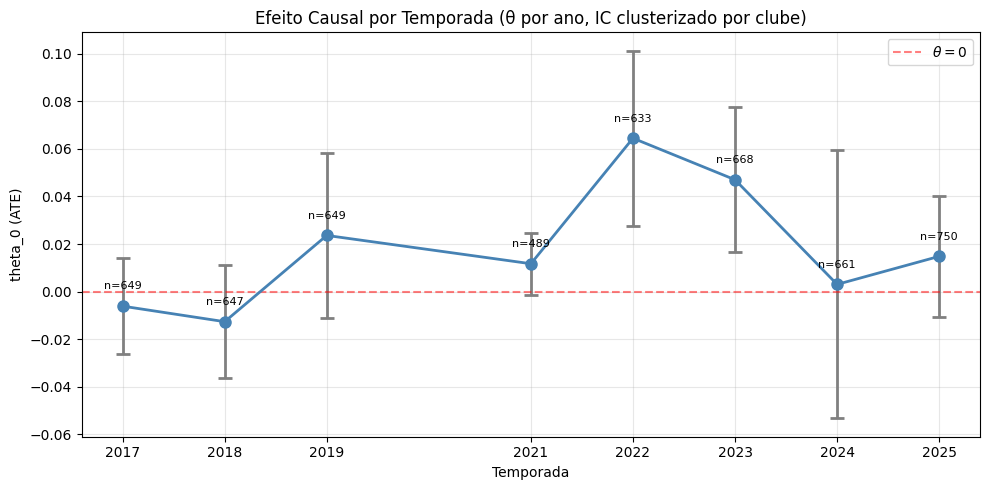

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(df_sazonal['season'], df_sazonal['theta'],
            yerr=[df_sazonal['theta']-df_sazonal['ci_low_cl'],
                  df_sazonal['ci_high_cl']-df_sazonal['theta']],
            fmt='o-', capsize=5, capthick=2, lw=2, ms=8, color='steelblue', ecolor='gray')
ax.axhline(0, color='red', ls='--', alpha=0.5, label=r'$\theta = 0$')
ax.set_xlabel('Temporada'); ax.set_ylabel('theta_0 (ATE)')
ax.set_title('Efeito Causal por Temporada (θ por ano, IC clusterizado por clube)')
ax.set_xticks(sorted(df_sazonal['season'].unique()))
ax.grid(alpha=0.3); ax.legend()
for _, r in df_sazonal.iterrows():
    ax.annotate(f'n={int(r["n"])}', (r['season'], r['theta']), xytext=(0,12), textcoords='offset points', ha='center', fontsize=8)
plt.tight_layout(); plt.show()

### Interpretação Sazonal

Com 8 temporadas e **erro-padrão clusterizado por clube**, o efeito é **concentrado em dois anos**:

- **2022 (θ = +0,064, p = 0,0006) e 2023 (θ = +0,047, p = 0,0024):** únicos anos com efeito positivo e significativo. Mais importante: **ambos sobrevivem à correção de Bonferroni (p = 0,005 e 0,019) e ao FDR de Benjamini-Hochberg** para os 8 testes sazonais. Não são, portanto, falsos-positivos do tipo "garden of forking paths". Correspondem ao boom pós-COVID, quando o mercado atingiu volumes recordes após 2 anos de restrição — escassez relativa de talento e urgência de reposição.
- **2017, 2018, 2019, 2021, 2024, 2025:** efeito não significativo (ICs clusterizados cruzam zero).

**Isso explica o ATE médio nulo:** o pool de 8 temporadas dilui o efeito de 2022–2023 com 6 anos sem efeito.

**Este é o achado confirmatório do trabalho:** o prêmio do vendedor **não** é uma lei do mercado — emerge em regime de mercado aquecido e some no restante. (Os efeitos ficaram ligeiramente maiores que na versão anterior porque o Y agora é out-of-fold, sem a compressão de variância do resíduo in-sample.)

### 6.1 Placebo dentro da temporada — validando 2022/2023

O placebo global (Seção 3) embaralha D na amostra inteira e só testa o efeito **médio**. Para testar o poder do desenho **onde o efeito vive**, fazemos um placebo de permutação **dentro de cada temporada**: embaralhamos D entre os clubes de 2022 (e de 2023), recalculamos θ, e repetimos 200×. Se o efeito de 2022/2023 fosse artefato, o θ observado cairia dentro da distribuição nula. O p-valor empírico é a fração de permutações com |θ| ≥ |θ observado|.

In [25]:
# Placebo de permutacao DENTRO da temporada (200 draws). ~2 min por safra.
def _theta_fast(Y, D, Wm, seed=SEED, K=5):
    """So o theta (sem SE) — RF de 120 arvores para o loop de permutacao ser rapido."""
    Y = np.asarray(Y, float); D = np.asarray(D, float); Wm = np.asarray(Wm, float)
    n = len(Y); yh = np.zeros(n); dh = np.zeros(n)
    for tr, te in KFold(K, shuffle=True, random_state=seed).split(Wm):
        yh[te] = RF(120, 5, seed).fit(Wm[tr], Y[tr]).predict(Wm[te])
        dh[te] = RF(120, 5, seed).fit(Wm[tr], D[tr]).predict(Wm[te])
    yr, dr = Y - yh, D - dh
    return float(np.polyfit(dr, yr, 1)[0])

NPERM = 200
placebo_season = {}
for yr in [2022, 2023]:
    m = df.season_id == yr
    Yv, Dv, Wv = df.loc[m,'Y'].values, df.loc[m,'D'].values, df.loc[m, CONFOUNDERS].values
    th_obs = _theta_fast(Yv, Dv, Wv)
    rng = np.random.default_rng(SEED)
    null = np.array([_theta_fast(Yv, rng.permutation(Dv), Wv, seed=SEED+i+1) for i in range(NPERM)])
    p_emp = (np.sum(np.abs(null) >= abs(th_obs)) + 1) / (NPERM + 1)
    placebo_season[yr] = {'theta_obs': th_obs, 'null_mean': null.mean(),
                          'null_sd': null.std(), 'q975': np.quantile(null, 0.975), 'p_emp': p_emp}
    print(f'{yr}: theta_obs={th_obs:+.4f} | nulo: media={null.mean():+.4f} sd={null.std():.4f} '
          f'q97.5={np.quantile(null,0.975):+.4f} | p_empirico(2 caudas)={p_emp:.4f}')

2022: theta_obs=+0.0643 | nulo: media=-0.0010 sd=0.0063 q97.5=+0.0113 | p_empirico(2 caudas)=0.0050


2023: theta_obs=+0.0436 | nulo: media=-0.0000 sd=0.0060 q97.5=+0.0116 | p_empirico(2 caudas)=0.0050


**Interpretação:** ao permutar D dentro da safra, θ colapsa para ≈ 0 (média do nulo ≈ 0, sd ≈ 0,006) e o θ observado (+0,064 em 2022; +0,044 em 2023) fica muito além do percentil 97,5 do nulo (~+0,012). O **p-valor empírico é 0,005** para ambos — o mínimo possível com 200 permutações. Este é o placebo mais informativo do trabalho: confirma que o efeito de 2022/2023 **não** é artefato do desenho, exatamente no regime onde ele vive.

## 7. Limitações

1. **Variáveis ausentes no dataset:** sem receita de patrocínio, classificação para UCL, dias restantes na janela de transferências.
2. **Granularidade temporal:** D reflete a temporada inteira, não os 30 dias anteriores à compra (como proposto originalmente). O efeito é diluído → estimativa conservadora.
3. **Controle de C1 (clube rico) por proxies:** o vetor W não inclui o bloco financeiro direto (`total_spend`, `n_buys`, `net_balance`) — isso seria *bad control* (mediadores/colliders). C1 é controlado via centralidade na rede e tamanho de elenco; é uma aproximação. A identificação repousa em *selection-on-observables* não testável (R² de 1ª etapa em Y = 0,06).
4. **Inferência:** usamos SE **clusterizado clube×temporada** (974 clusters) além do HC1, e **correção de múltiplas comparações** (Bonferroni/FDR) nos 8 testes sazonais. 2022/2023 sobrevivem.
5. **Achados exploratórios (não confirmatórios):** (a) o "mecanismo de sinalização" (D₂/D₃) **não sobrevive** ao controle de intensidade de janela; (b) o teste de lag (C2) é direcionalmente tranquilizador mas **não conclusivo** (o contemporâneo é n.s. na mesma amostra); (c) o **IVB** é dominado por outlier — ilustrativo.
6. **CATE/IVB via R-learner:** o `econml` (CausalForestDML) não instala no ambiente (Python 3.12 + NumPy 2.x). Os números de CATE/IVB não são diretamente comparáveis ao desenho original.
7. **2020 ausente** (COVID) e **2021 sob regime COVID** — registrados nos efeitos fixos de temporada, mas merecem nota.

## 8. Exportacao dos Resultados

In [26]:
output_path = '../output/resultados_etapa2_ivb.csv'
ivb_clubes_sorted = ivb_clubes.sort_values('ivb_pct', ascending=False).copy()
ivb_clubes_sorted['rank'] = range(1, len(ivb_clubes_sorted) + 1)
ivb_clubes_sorted.to_csv(output_path, index=False)
print(f'Exportado: {output_path} ({len(ivb_clubes_sorted)} clubes) — APENDICE ILUSTRATIVO')

Exportado: ../output/resultados_etapa2_ivb.csv (190 clubes) — APENDICE ILUSTRATIVO


In [27]:
print('='*64)
print('RESUMO -- ETAPA 2: DOUBLE MACHINE LEARNING')
print('='*64)
print()
print('ATE (Efeito Causal Medio):')
print(f'  theta_0 = {theta_0:.6f}')
print(f'  IC HC1:     [{ci[0]:.6f}, {ci[1]:.6f}]  {"sig" if (ci[0]>0 or ci[1]<0) else "n.s."}')
print(f'  IC cluster: [{ci_cl[0]:.6f}, {ci_cl[1]:.6f}]  {"sig" if (ci_cl[0]>0 or ci_cl[1]<0) else "n.s."}')
print()
print('Validacao (placebos):')
print(f'  Placebo shuffle: theta = {theta_p1:.6f}  IC: [{ci_p1[0]:.6f}, {ci_p1[1]:.6f}]')
print(f'  Placebo noise:  theta = {theta_p2:.6f}  IC: [{ci_p2[0]:.6f}, {ci_p2[1]:.6f}]')
print(f'  R2 model_y: {r2_y:.4f}, R2 model_t: {r2_t:.4f}')
print()
print('IVB -- Top 5 Presas Faceis (APENDICE ILUSTRATIVO, percentil):')
for _, r in top_presas.head(5).iterrows():
    print(f'  {r["buyer"]}: IVB_pct={r["ivb_pct"]:.3f} ({int(r["n_transacoes"])} transacoes)')
print()
print('Efeito por Temporada (IC clusterizado | sig. apos Bonferroni):')
for _, r in df_sazonal.iterrows():
    sig_s = r['ci_low_cl'] > 0 or r['ci_high_cl'] < 0
    print(f'  {"+" if sig_s else "-"} {int(r["season"])}: theta={r["theta"]:.6f}  '
          f'IC=[{r["ci_low_cl"]:.6f}, {r["ci_high_cl"]:.6f}]  '
          f'p_bonf={r["p_bonferroni"]:.4f} {"(sobrevive)" if r["sig_bonf"] else ""}  (n={int(r["n"])})')
print()
print(f'>> Achado confirmatorio (sobrevive a Bonferroni): '
      f'{df_sazonal.loc[df_sazonal["sig_bonf"], "season"].tolist()}')

RESUMO -- ETAPA 2: DOUBLE MACHINE LEARNING

ATE (Efeito Causal Medio):
  theta_0 = 0.004415
  IC HC1:     [-0.001586, 0.010416]  n.s.
  IC cluster: [-0.002129, 0.010959]  n.s.

Validacao (placebos):
  Placebo shuffle: theta = 0.002441  IC: [-0.001888, 0.006770]
  Placebo noise:  theta = 0.000882  IC: [-0.003557, 0.005321]
  R2 model_y: 0.0606, R2 model_t: 0.3739

IVB -- Top 5 Presas Faceis (APENDICE ILUSTRATIVO, percentil):
  Nîmes Olympique: IVB_pct=1.000 (8 transacoes)
  KV Mechelen: IVB_pct=0.995 (18 transacoes)
  Sunderland AFC: IVB_pct=0.989 (14 transacoes)
  VfL Bochum: IVB_pct=0.984 (6 transacoes)
  SSC Napoli: IVB_pct=0.979 (52 transacoes)

Efeito por Temporada (IC clusterizado | sig. apos Bonferroni):
  - 2017: theta=-0.006076  IC=[-0.026127, 0.013975]  p_bonf=1.0000   (n=649)
  - 2018: theta=-0.012606  IC=[-0.036259, 0.011048]  p_bonf=1.0000   (n=647)
  - 2019: theta=0.023636  IC=[-0.011045, 0.058316]  p_bonf=1.0000   (n=649)
  - 2021: theta=0.011743  IC=[-0.001363, 0.024849]